In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

scale = 0.11
interval = 10
threshold = 0.015

def get_wait(path, threshold=0.015, interval = 10, pos_window=None):
    track = cv.cal(pd.read_csv(path), scale, interval, pos_window=pos_window, pos_center=True)
    wt = cv.low_area(track, threshold=threshold, min_low_duration=1,time_interval=interval, xlabel = 'time(sec)', ylabel = 'velocity(um/s)', ylim = (0.0, 0.7), display = False)
    tt = cv.pulses(track, threshold=threshold, time_interval=interval, display = False)

    return wt, tt

def wait_df(path_list, threshold=0.015, interval = 10, pos_window=None):
    wts = []
    tts = []

    i = 0
    for path in path_list:
        wt, tt = get_wait(path, threshold=threshold, interval = interval, pos_window=pos_window)
        wt['particle'] += i*10000
        tt['particle'] += i*10000
        wts.append(wt)
        tts.append(tt)
        i += 1

    wts = pd.concat(wts)
    tts = pd.concat(tts)

    return wts, tts

In [2]:
threshold = 0.015


path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240827/MC00/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC00MT1uM/beads_tracks.csv"

MC10 = [path1, path2]
wt10, tt10 = wait_df(MC10, pos_window=3)

path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM001/beads_tracks.csv"
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC03MT1uM/beads_tracks.csv"
path4 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241127/MC03MT1uM/beads_tracks.csv"

MC13 = [path1, path2, path3, path4]
wt13, tt13 = wait_df(MC13, pos_window=3)

wt40, tt40 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC00MT4uM/beads_tracks.csv", pos_window=3)
wt43, tt43 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC03MT4uM/beads_tracks.csv", pos_window=3)

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: Futu

(array([0, 1]),)
(array([0, 1]),)
(array([0, 1]),)
(array([0, 1, 2]),)


<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/3939028257.py:29: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/3939028257.py:30: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/3939028257.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


"\nfig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')\nfig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')\n"

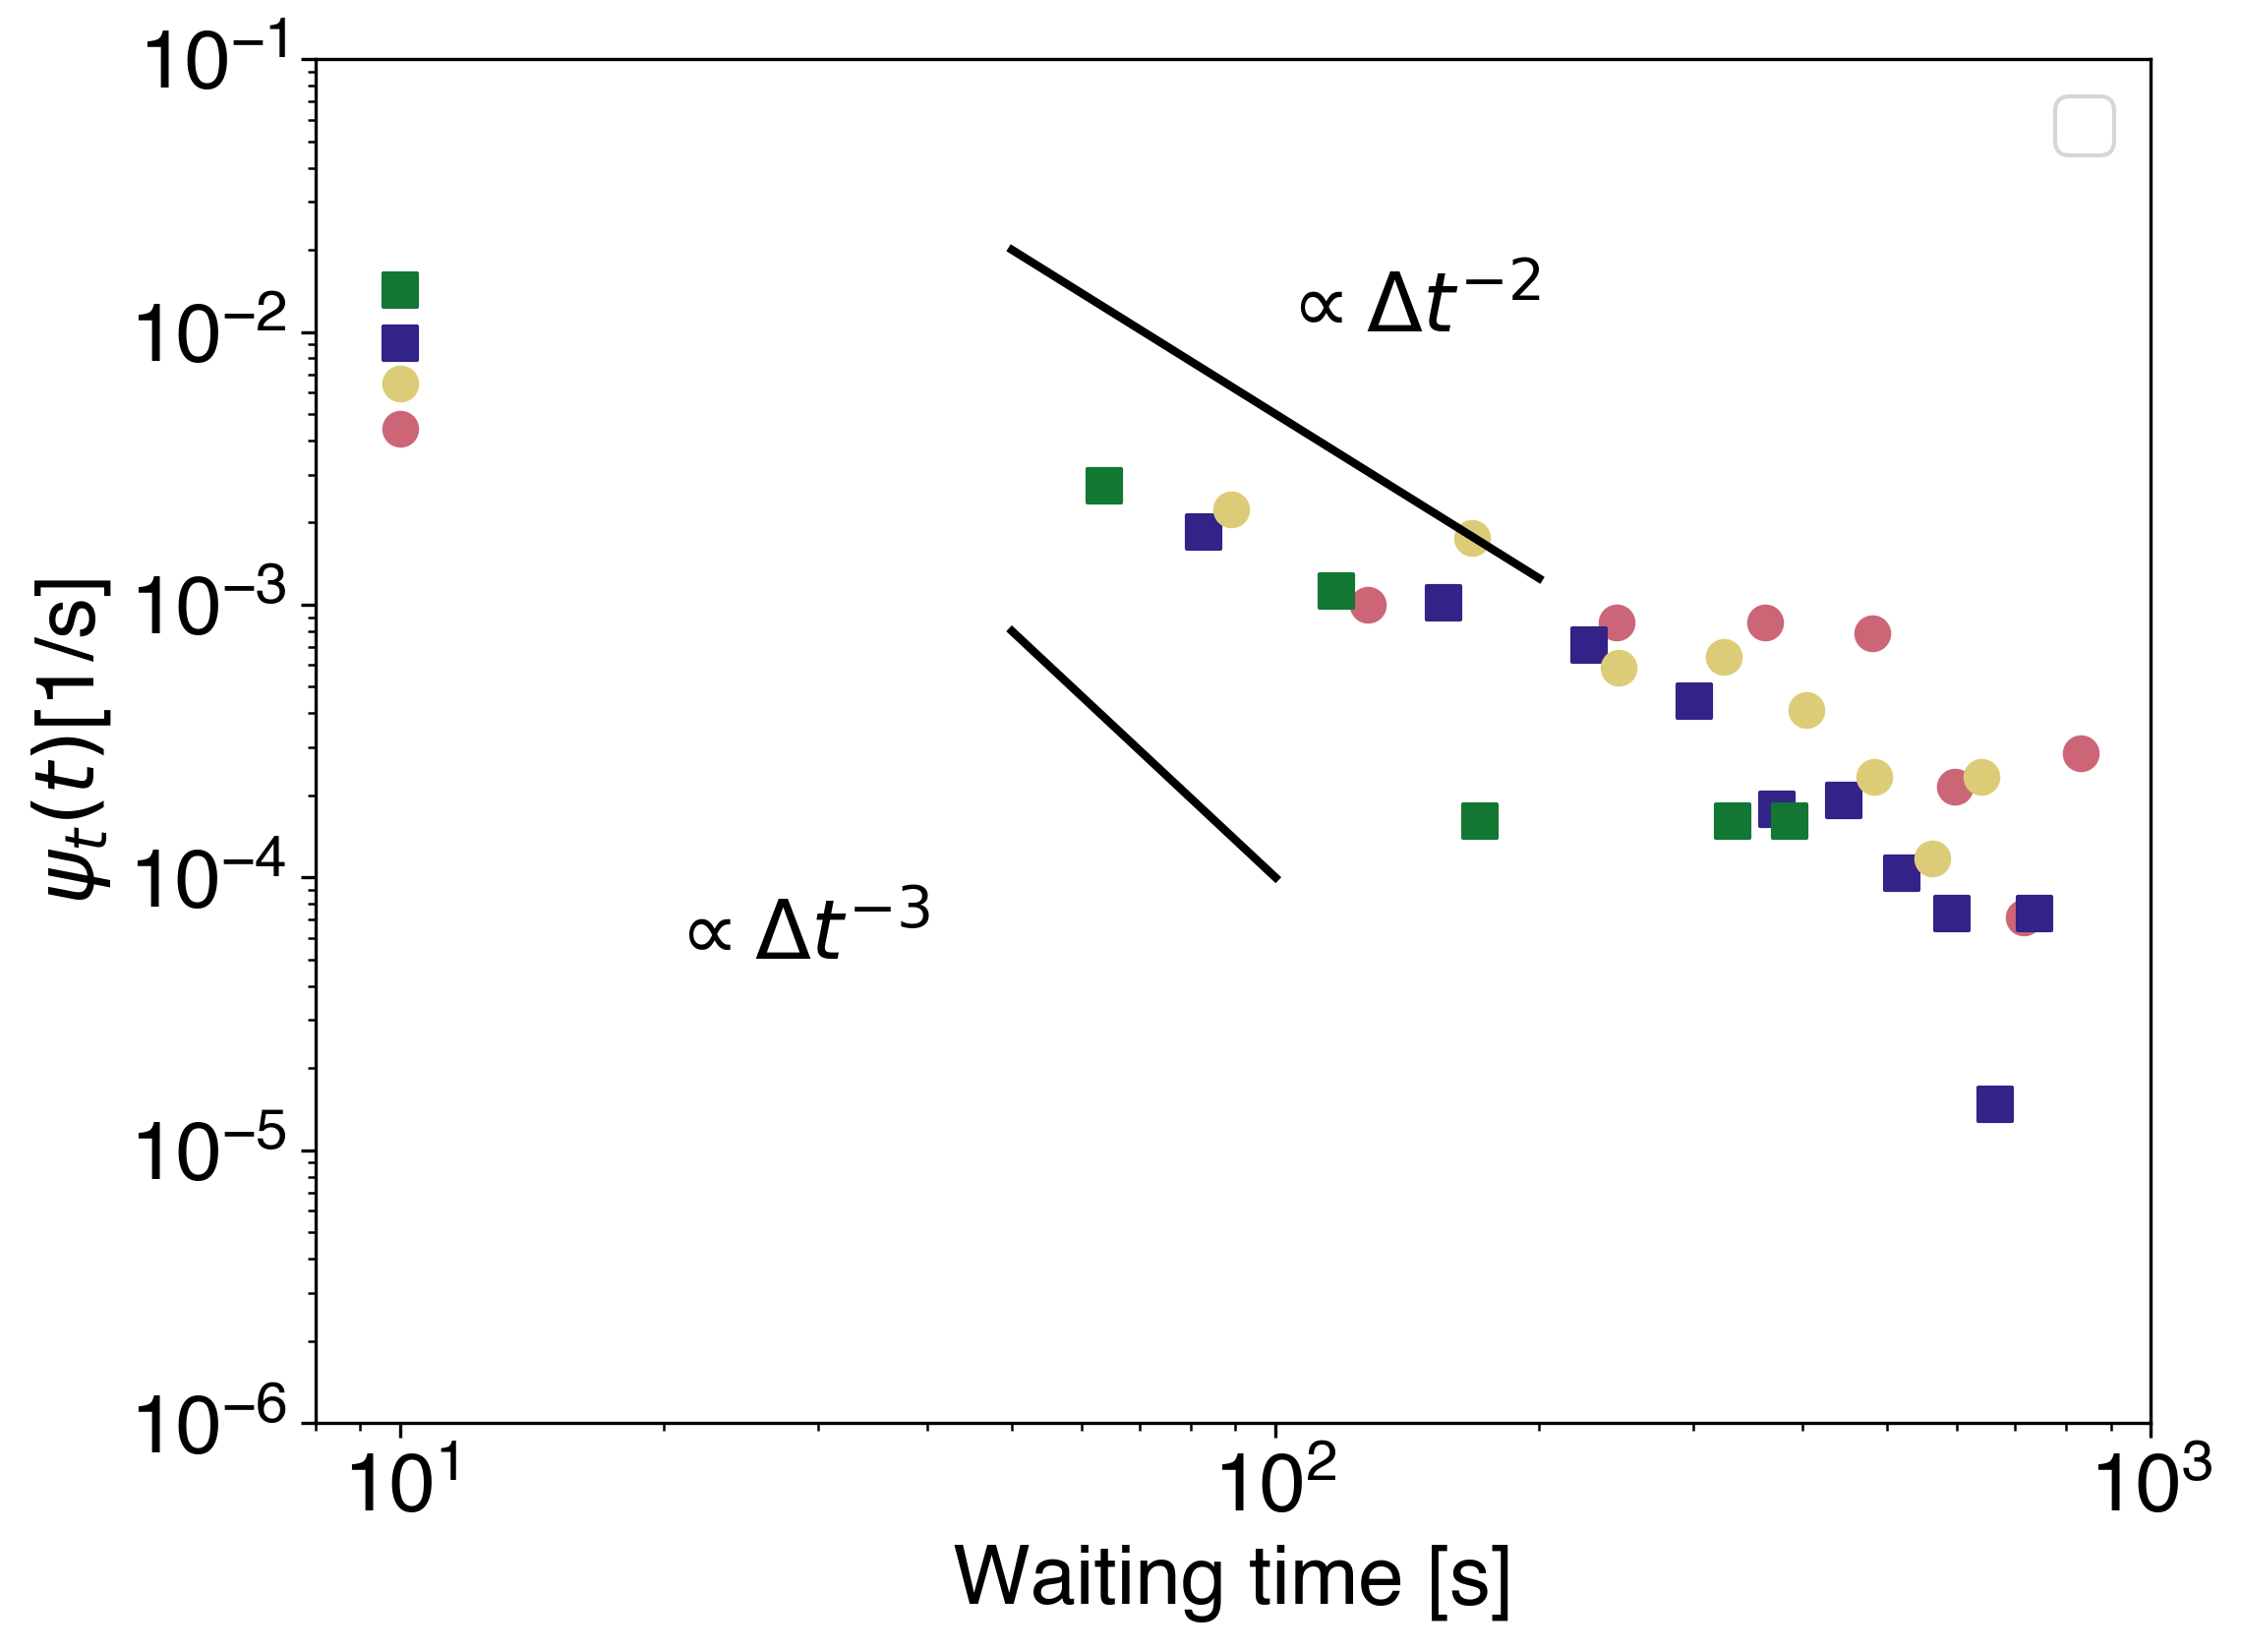

In [3]:
min_fit, max_fit = 10,150

def get_hist(df, min_fit, max_fit, marker, label=None):
    data = df['interval'].values
    # ヒストグラムのデータを計算
    bins = np.histogram_bin_edges(data, 'sturges')
    counts, bin_edges = np.histogram(data, bins, density = True)
    indices = np.where((counts>0) & (bin_edges[:-1]>=min_fit) & (bin_edges[:-1]<=max_fit))
    print(indices)
    #popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))
    #fit = fm.power_law(bins, popt[0], popt[1])
    ax.scatter(bin_edges[:-1], counts, marker=markers[marker], label = label)
    #ax.plot(bins, fit, color = colors[color], lw = lw, linestyle=lines[line])
    #print(f"MT{MT_conc[MT]}uM MC{mc_conc[mc]}%, {np.abs(popt[0]+1)}")
    
    return counts, bin_edges #, popt, pcov

fig, ax  = plt.subplots()
get_hist(wt10, min_fit, max_fit, marker=0)
get_hist(wt13, min_fit, max_fit, marker=1)
get_hist(wt40, min_fit, max_fit, marker=0)
get_hist(wt43, min_fit, max_fit, marker=1)

ty = np.linspace(50, 200, 10)
ax.plot(ty, 5*1e1*ty**-2, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e2*ty2**-3, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')

ax.legend()

ax.set(xlim=(0.8*1e1,1000),
       ylim=(1e-6, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_t(t)$[1/s]')
"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""

(array([3, 4, 5]),)
(array([1]),)
(array([2]),)
(array([1, 2]),)


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/2217833454.py:14: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-1}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/2217833454.py:15: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-2}$')


[(8.0, 1000.0),
 (1e-06, 0.1),
 None,
 None,
 Text(0.5, 0, 'Waiting time [s]'),
 Text(0, 0.5, '$\\psi_r(t)$[1/s]')]

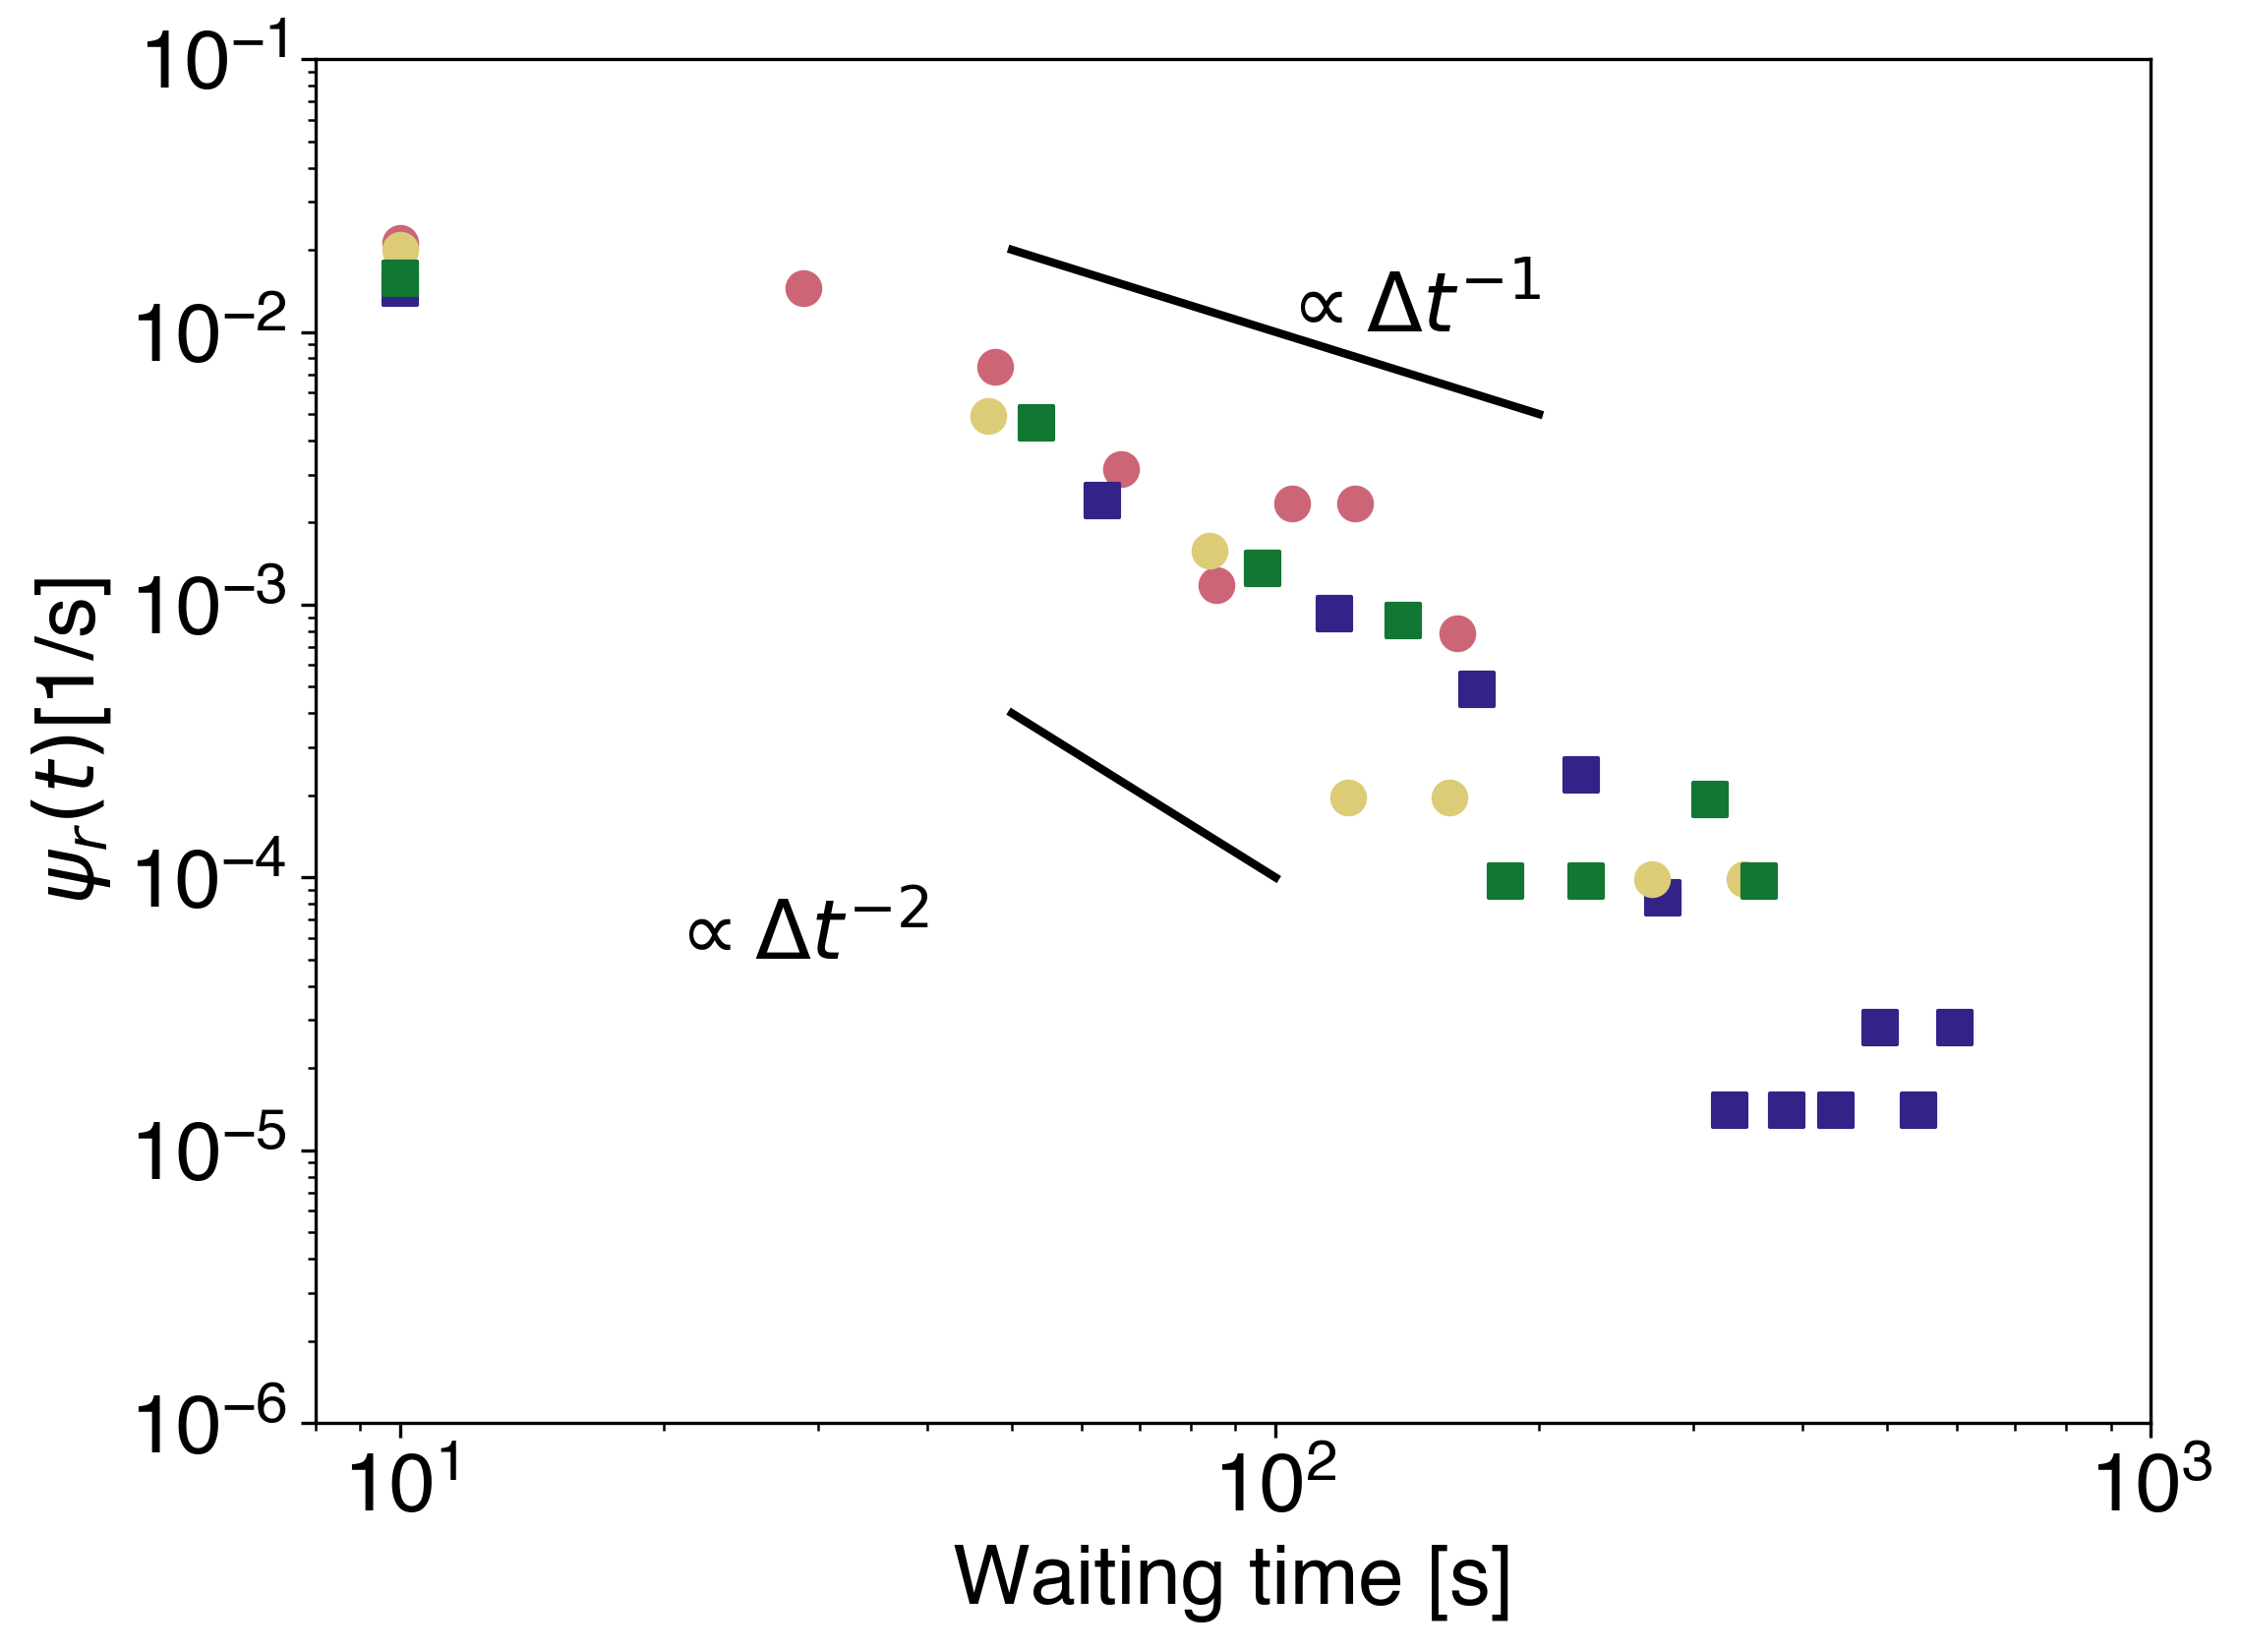

In [4]:
min_fit, max_fit = 50,110
fig, ax  = plt.subplots()

get_hist(tt10, min_fit, max_fit, marker=0)
get_hist(tt13, min_fit, max_fit, marker=1)
get_hist(tt40, min_fit, max_fit, marker=0)
get_hist(tt43, min_fit, max_fit, marker=1)

ty = np.linspace(50, 200, 10)
ax.plot(ty, 1e0*ty**-1, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e0*ty2**-2, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-1}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-2}$')

ax.set(xlim=(0.8 * 1e1,1000),
       ylim=(1e-6, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_r(t)$[1/s]')

In [ ]:
wt03, tt03 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251225/MC03MT/beads_tracks.csv", threshold=0.11, interval=2)
wt00, tt00 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251226/MC00MT/beads_tracks.csv", threshold=0.11, interval=2)

wt43, tt43 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260107/MC03MT10/beads_tracks.csv", threshold=0.11, interval=2)


/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: Futu

(array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 26, 27, 28, 29, 30, 33, 35, 36, 38, 39, 44, 46, 47, 53,
       60]),)
(array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 39, 40, 41, 43,
       45, 46, 48, 49, 50, 53, 55, 58]),)
(array([ 5,  7,  8,  9, 10, 11, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64,
       69, 74]),)


"\nfig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')\nfig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')\n"

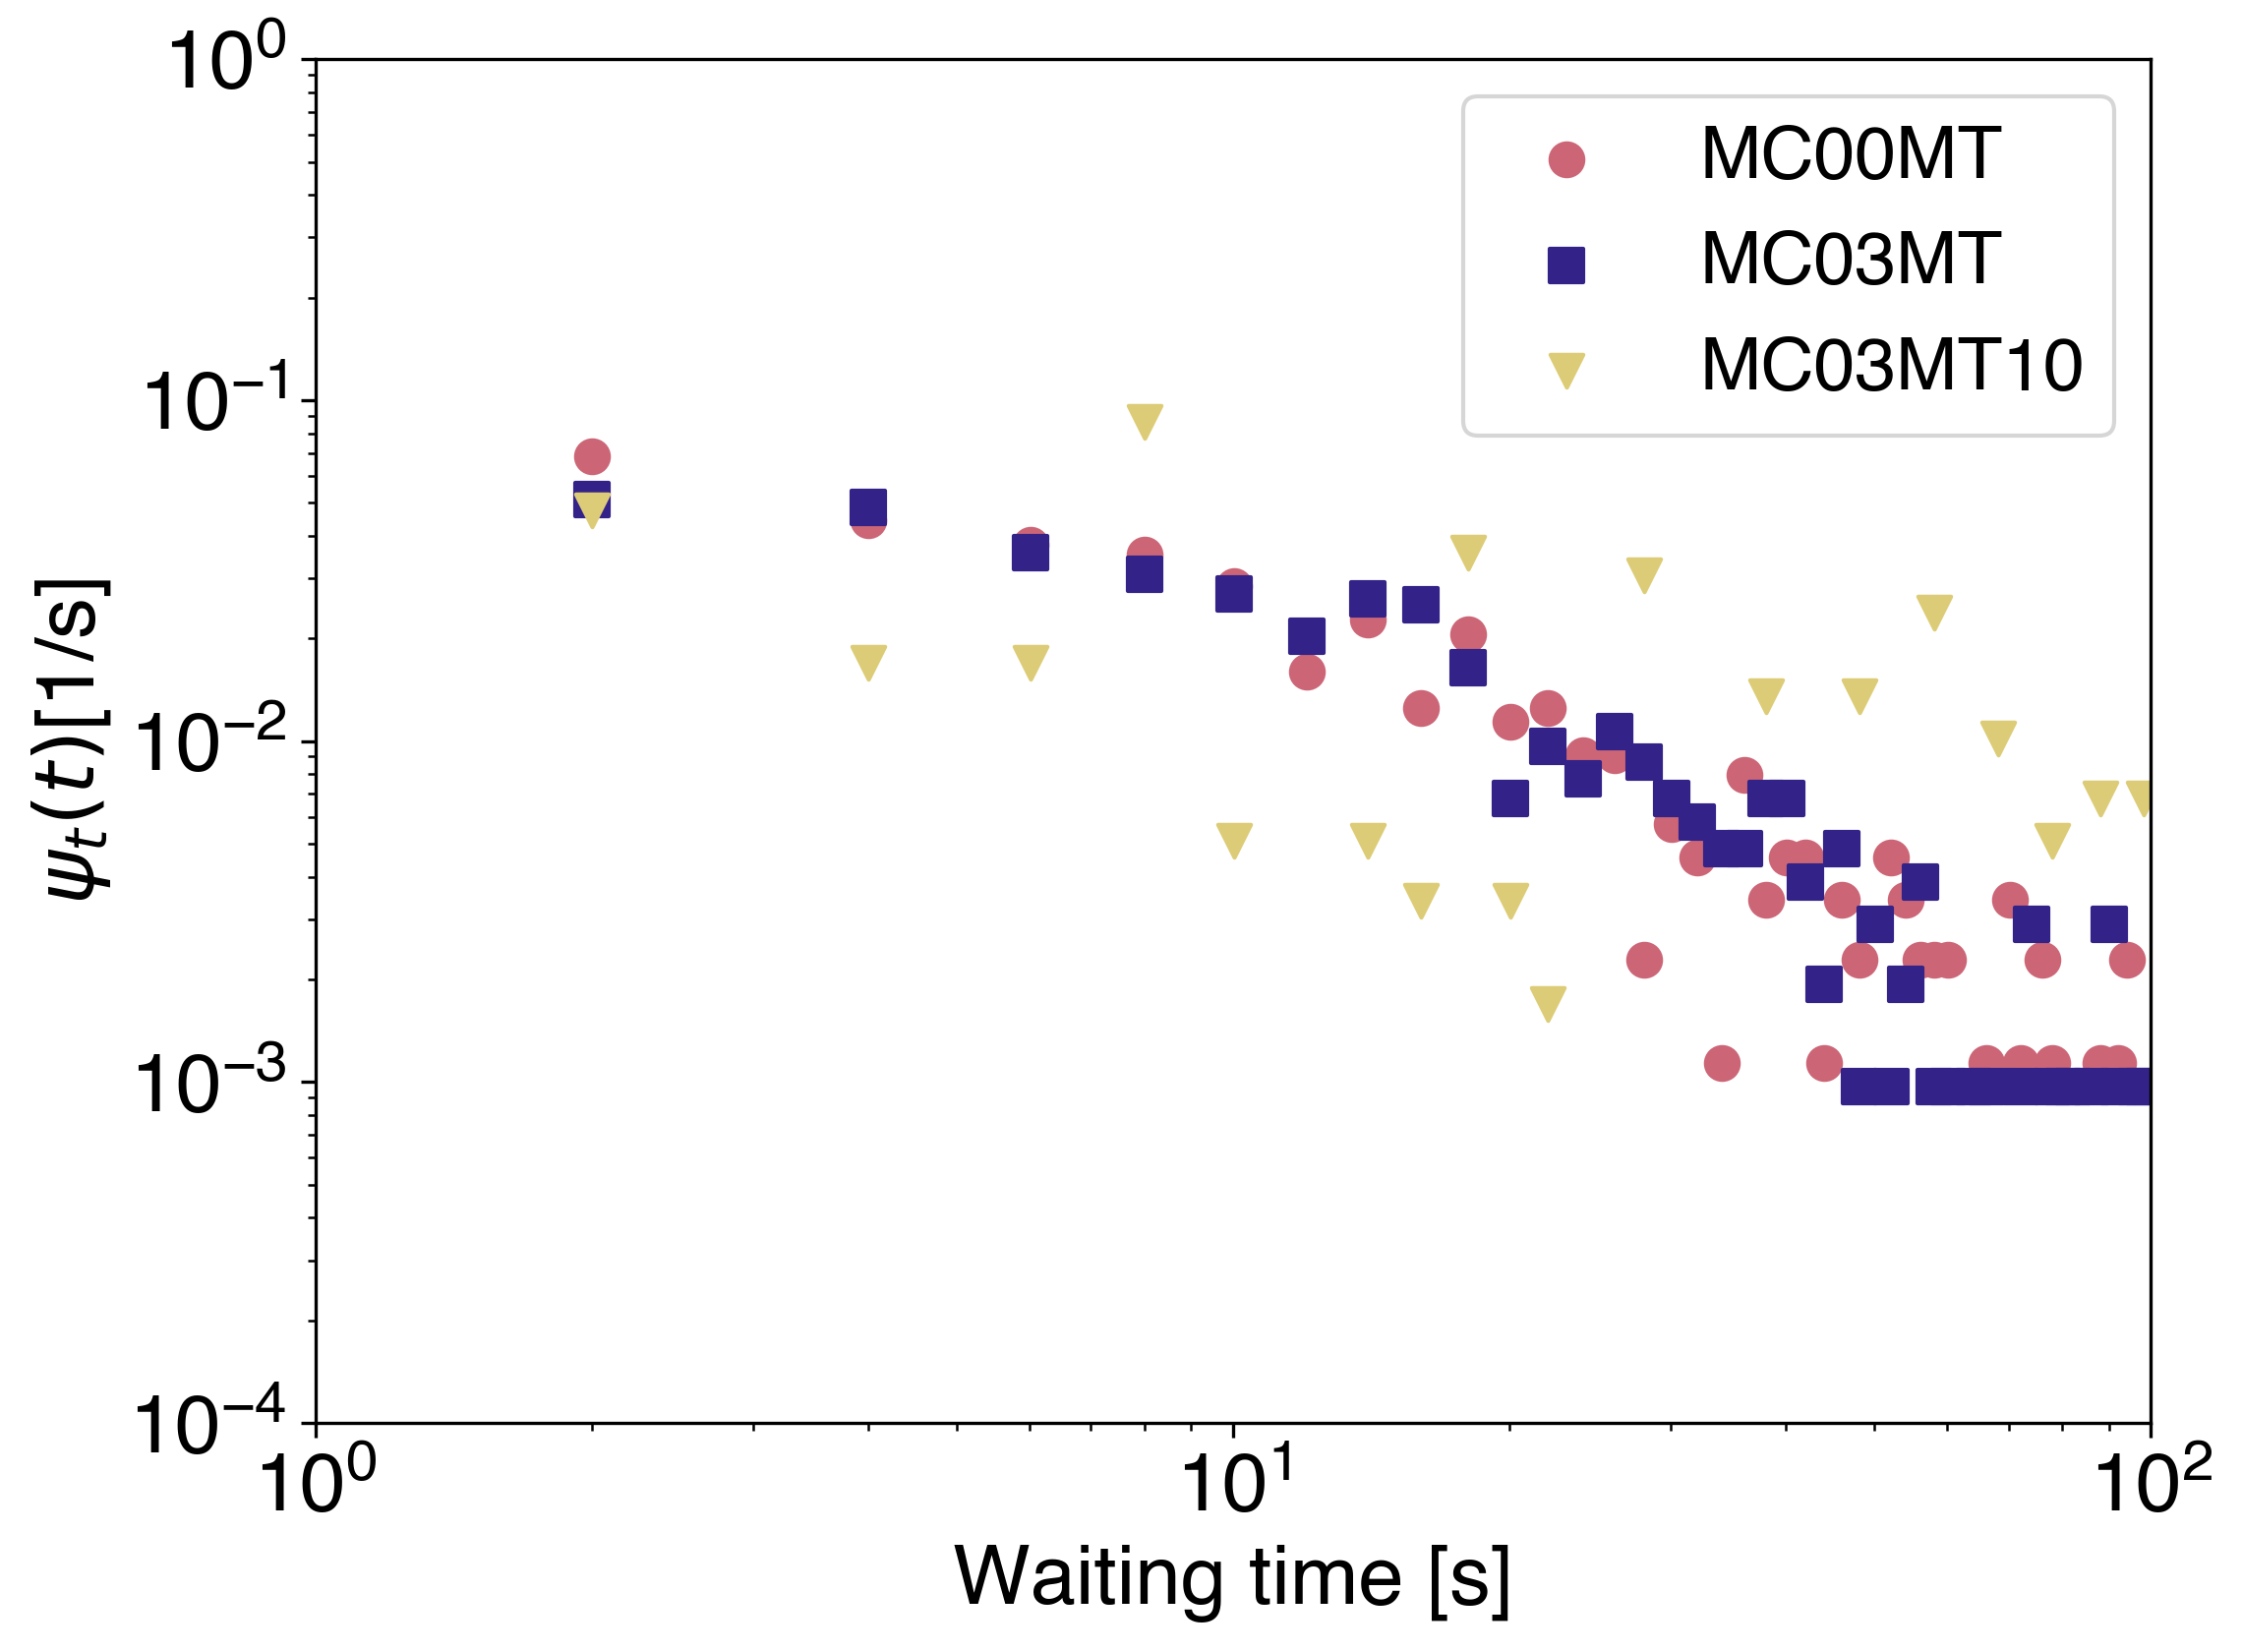

In [4]:
min_fit, max_fit = 10,150

def get_hist(df, min_fit, max_fit, marker, label=None):
    data = df['interval'].values
    # ヒストグラムのデータを計算
    bins = np.linspace(0, 1000, 500) #np.histogram_bin_edges(data, 'sturges')
    counts, bin_edges = np.histogram(data, bins, density = True)
    indices = np.where((counts>0) & (bin_edges[:-1]>=min_fit) & (bin_edges[:-1]<=max_fit))
    print(indices)
    #popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))
    #fit = fm.power_law(bins, popt[0], popt[1])
    ax.scatter(bin_edges[:-1], counts, marker=markers[marker], label = label)
    #ax.plot(bins, fit, color = colors[color], lw = lw, linestyle=lines[line])
    #print(f"MT{MT_conc[MT]}uM MC{mc_conc[mc]}%, {np.abs(popt[0]+1)}")
    
    return counts, bin_edges, #popt, pcov

fig, ax  = plt.subplots()

get_hist(wt00, min_fit, max_fit, marker=0, label='MC00MT')
get_hist(wt03, min_fit, max_fit, marker=1, label='MC03MT')
get_hist(wt43, min_fit, max_fit, marker=2, label='MC03MT10')

ax.legend()

ax.set(xlim=(1,100),
       ylim=(1e-4, 1e-0),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_t(t)$[1/s]')

"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""

(array([ 5,  6,  7,  8, 10, 14, 30, 40]),)
(array([ 5,  6,  7,  8,  9, 10, 11, 13, 15, 16, 17, 25, 32, 34, 37, 41, 45,
       61]),)
(array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 19, 21, 22, 26, 27,
       28, 29, 53]),)


"\nfig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')\nfig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')\n"

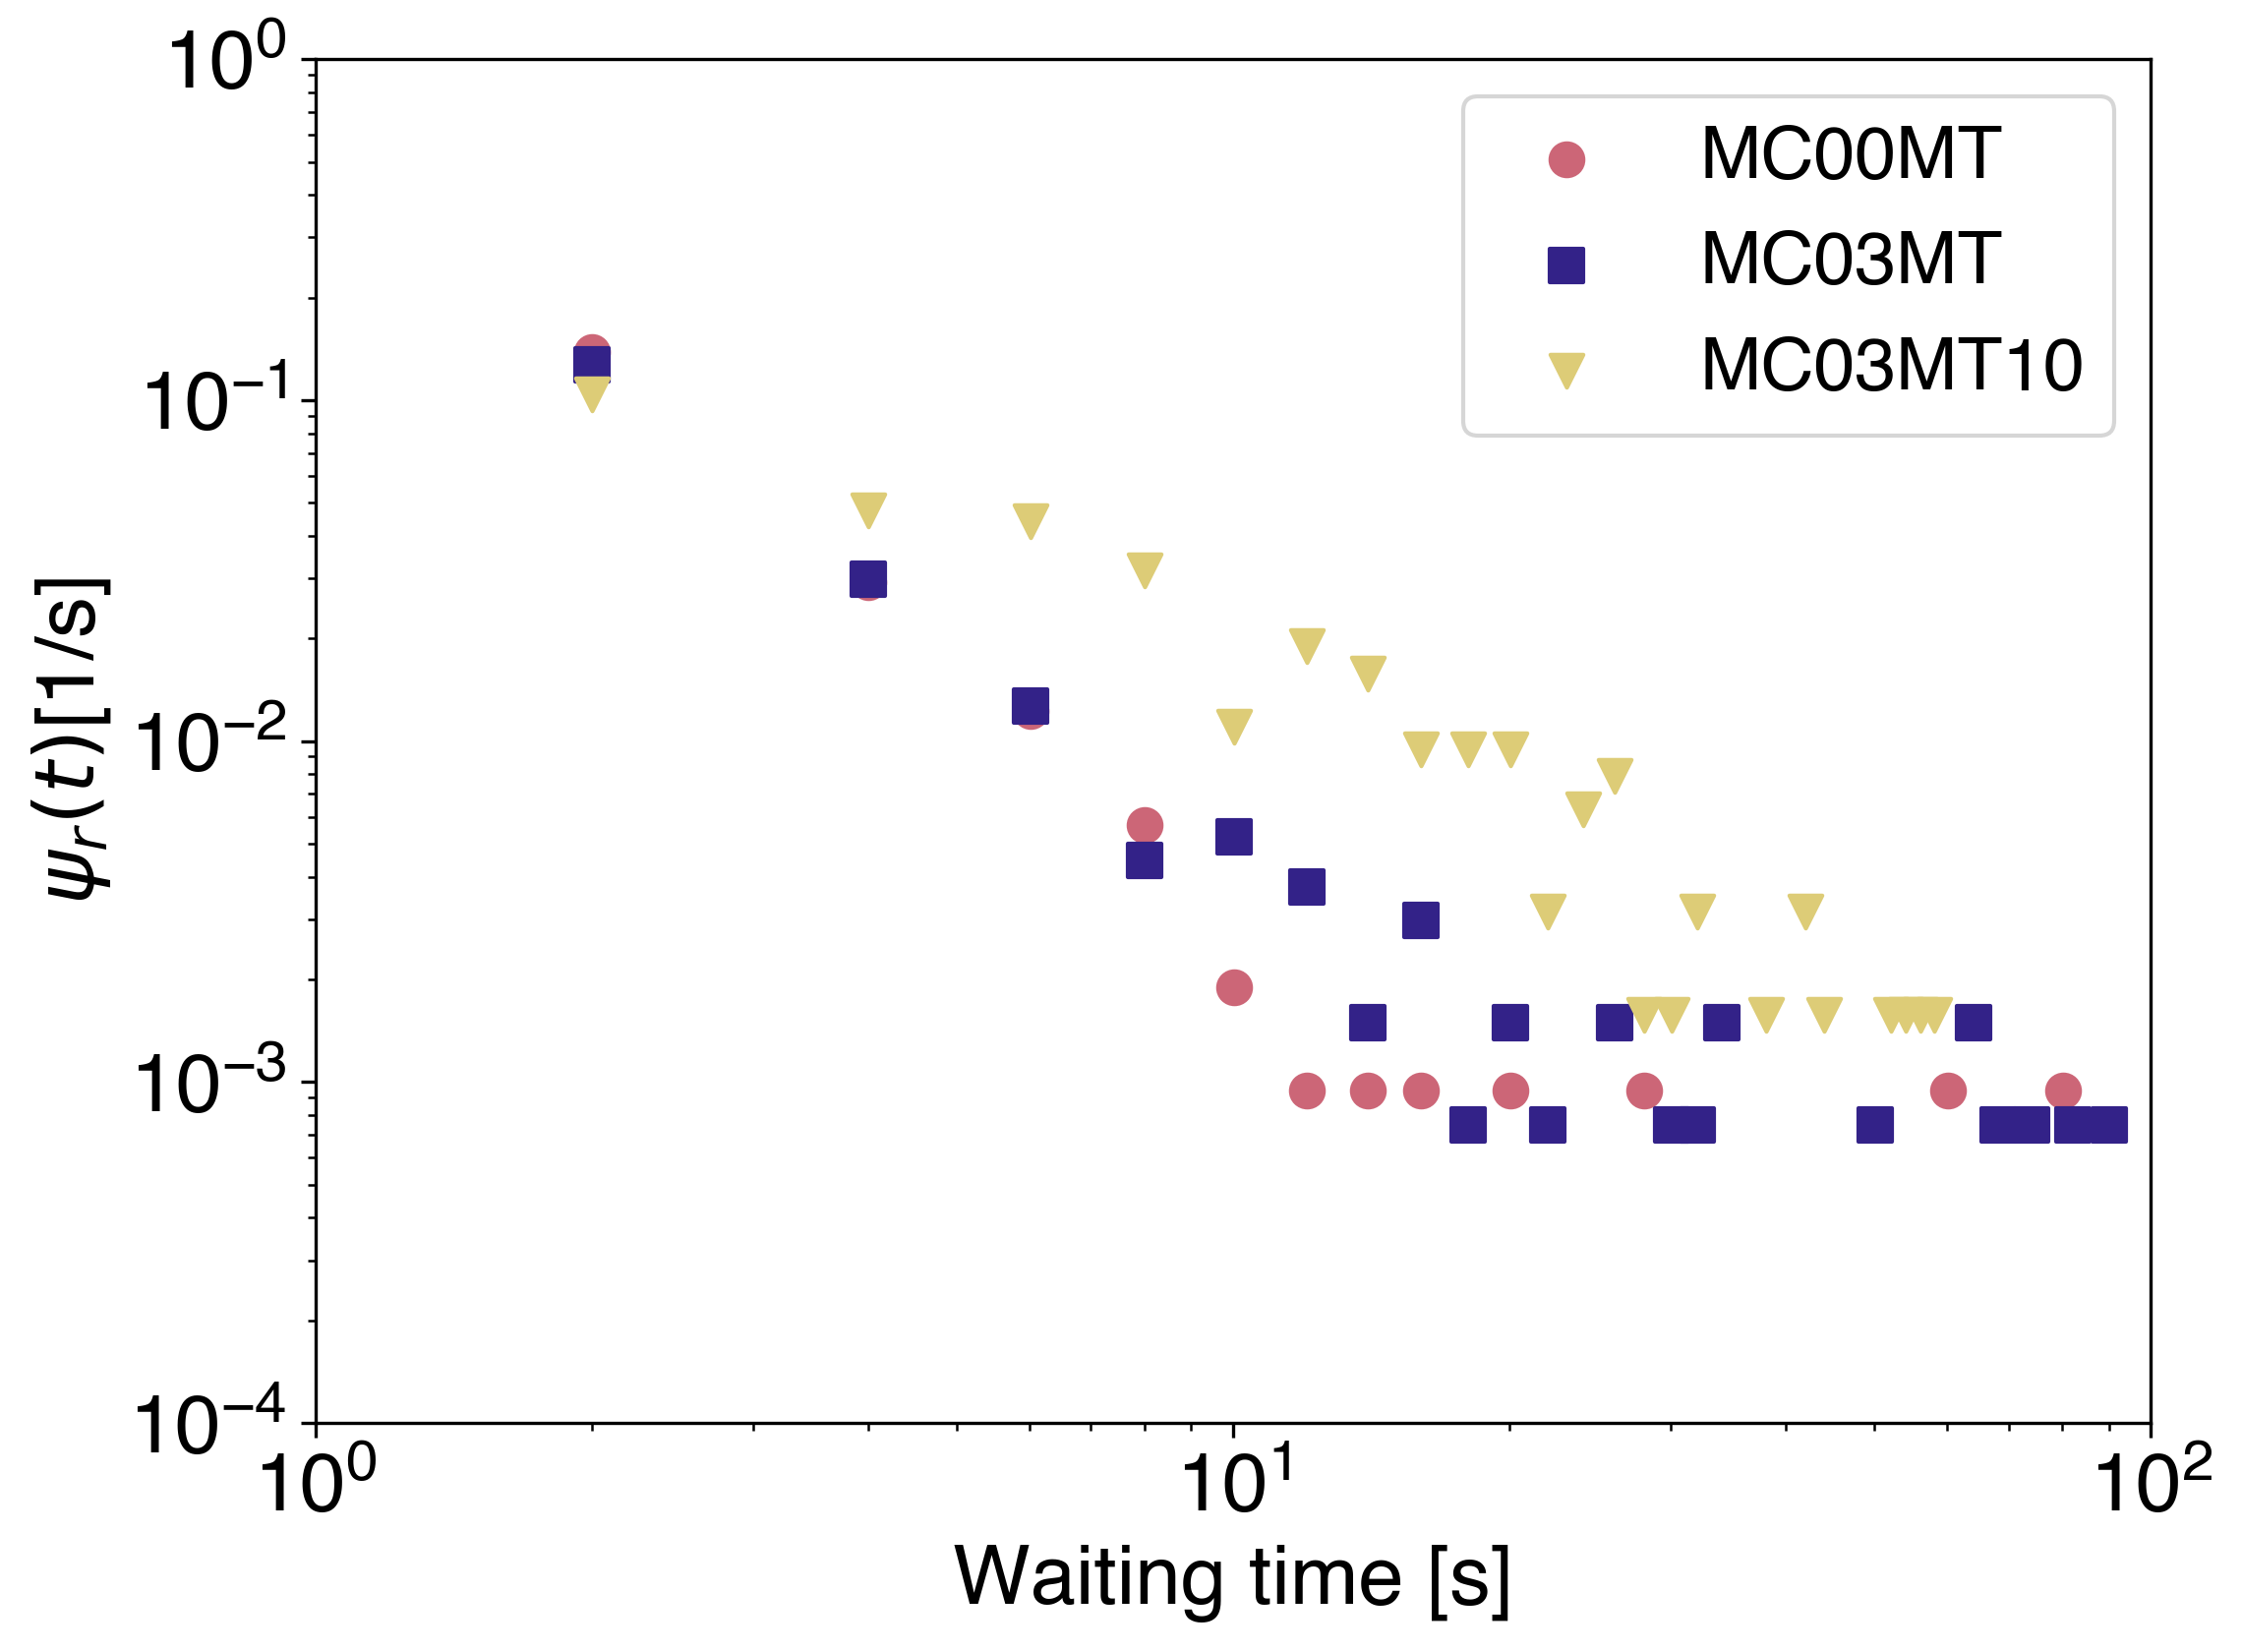

In [10]:
min_fit, max_fit = 10,150

def get_hist(df, min_fit, max_fit, marker, label=None):
    data = df['interval'].values
    # ヒストグラムのデータを計算
    bins = np.linspace(0, 1000, 500) #np.histogram_bin_edges(data, 'sturges')
    counts, bin_edges = np.histogram(data, bins, density = True)
    indices = np.where((counts>0) & (bin_edges[:-1]>=min_fit) & (bin_edges[:-1]<=max_fit))
    print(indices)
    #popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))
    #fit = fm.power_law(bins, popt[0], popt[1])
    ax.scatter(bin_edges[:-1], counts, marker=markers[marker], label = label)
    #ax.plot(bins, fit, color = colors[color], lw = lw, linestyle=lines[line])
    #print(f"MT{MT_conc[MT]}uM MC{mc_conc[mc]}%, {np.abs(popt[0]+1)}")
    
    return counts, bin_edges, #popt, pcov

fig, ax  = plt.subplots()


get_hist(tt00, min_fit, max_fit, marker=0, label='MC00MT')
get_hist(tt03, min_fit, max_fit, marker=1, label='MC03MT')
get_hist(tt43, min_fit, max_fit, marker=2, label='MC03MT10')

ax.legend()

ax.set(xlim=(1,100),
       ylim=(1e-4, 1e-0),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_r(t)$[1/s]')

"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""

In [8]:
threshold = 0.03


path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240827/MC00/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC00MT1uM/beads_tracks.csv"

MC10 = [path1, path2]
wt10, tt10 = wait_df(MC10, threshold)

path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM001/beads_tracks.csv"
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC03MT1uM/beads_tracks.csv"
path4 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241127/MC03MT1uM/beads_tracks.csv"

MC13 = [path1, path2, path3, path4]
wt13, tt13 = wait_df(MC13, threshold)

wt40, tt40 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC00MT4uM/beads_tracks.csv", threshold)
wt43, tt43 = get_wait("/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC03MT4uM/beads_tracks.csv", threshold)

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: Futu

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/2266267360.py:15: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/2266267360.py:16: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/2266267360.py:15: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64872/2266267360.py:16: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')


(array([ 9, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74]),)


ValueError: not enough values to unpack (expected 4, got 2)

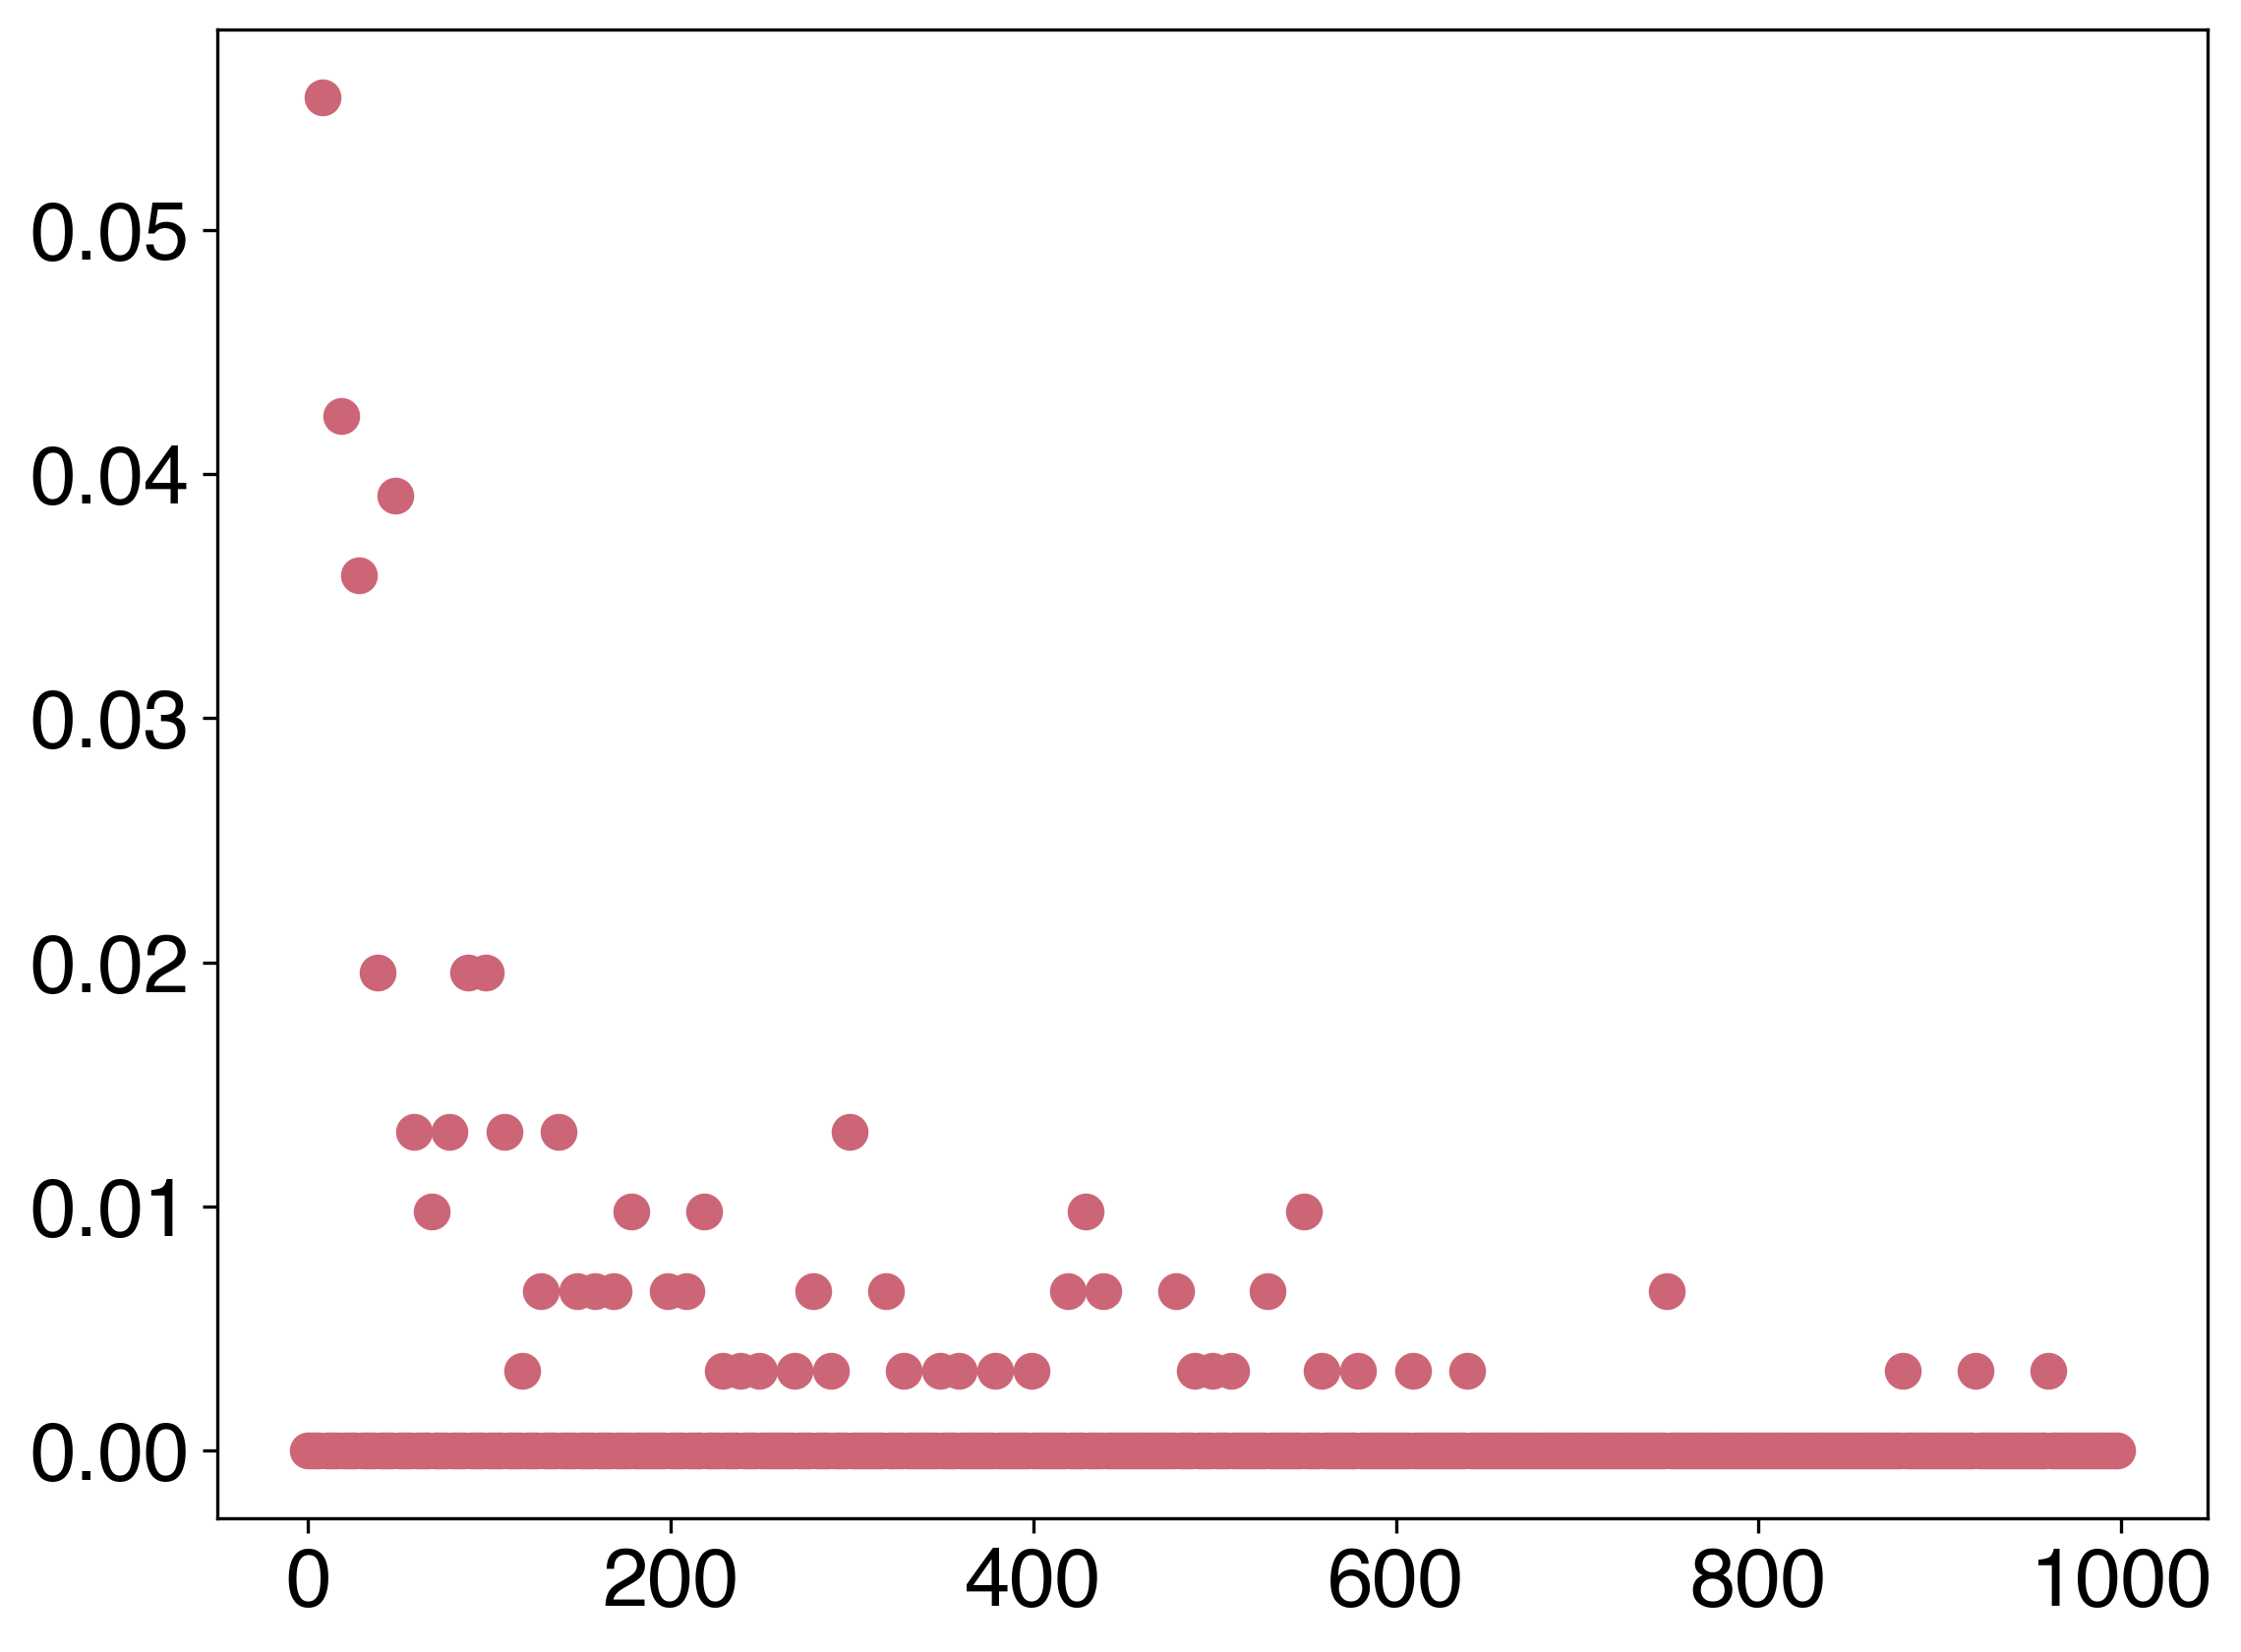

In [9]:
min_fit, max_fit = 10,150

fig, ax  = plt.subplots()

counts, bin_edges, popt, _ = get_hist(wt10, min_fit, max_fit, marker=0)
counts, bin_edges, popt, _ = get_hist(wt13, min_fit, max_fit, marker=1)
counts, bin_edges, popt, _ = get_hist(wt40, min_fit, max_fit, marker=0)
counts, bin_edges, popt, _ = get_hist(wt43, min_fit, max_fit, marker=1)

ty = np.linspace(50, 200, 10)
ax.plot(ty, 5*1e1*ty**-2, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e2*ty2**-3, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')

ax.legend()

ax.set(xlim=(0.8*1e1,1000),
       ylim=(1e-6, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_t(t)$[1/s]')
"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""